# Bitcoin Price Movement Prediction: LSTM & Sentiment Analysis

This notebook establishes a rolling-window deep learning pipeline to predict Bitcoin price movements using a Long Short-Term Memory (LSTM) neural network. It evaluates the predictive power of various technical indicator combinations, candlestick anatomy/patterns, and hourly sentiment data by capturing sequential dependencies over time.

## 1. Data Loading and Preprocessing
* **Inputs:** `Bitcoin_sentiment_hourly.csv`, `btc_hourly_indicators.csv`, and `btc_hourly_candlestick.csv`
* **Alignment:** Inner merge on `timestamp`. Data is strictly filtered to start from `2018-01-01`.
* **Target Variable:** The continuous return of the next hour (`next_1h_return`), allowing for robust regression error metrics (RMSE, SMAPE) and derivable classification states (Bullish > 0, Bearish <= 0).

In [1]:
import torch

# ==========================================
# GPU ACCELERATION MANAGEMENT (PYTORCH)
# ==========================================
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ PyTorch GPU Accelerated Training Enabled. Found GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("❌ No GPU found. PyTorch is running on the slow CPU.")

import pandas as pd
import numpy as np
import warnings
from hmmlearn.hmm import GaussianHMM 
warnings.filterwarnings('ignore')

# --- 1. Load Datasets ---
print("Loading datasets...")
df_indicators = pd.read_csv('btc_hourly_indicators.csv')
df_sentiment = pd.read_csv('Bitcoin_sentiment_hourly.csv')
df_candles = pd.read_csv('btc_hourly_candlestick.csv') # NEW: Load Candlestick data

# --- 2. Robust Datetime Conversion ---
print("Converting timestamps using ISO8601 format...")
df_indicators['timestamp'] = pd.to_datetime(df_indicators['timestamp'], utc=True, format='ISO8601')
df_sentiment['timestamp'] = pd.to_datetime(df_sentiment['timestamp'], utc=True, format='ISO8601')
df_candles['timestamp'] = pd.to_datetime(df_candles['timestamp'], utc=True, format='ISO8601')

# --- 3. Filter to 2018 Onwards ---
start_date = pd.to_datetime('2018-01-01 00:00:00', utc=True)
print(f"Filtering data from {start_date}...")
df_indicators = df_indicators[df_indicators['timestamp'] >= start_date]
df_sentiment = df_sentiment[df_sentiment['timestamp'] >= start_date]
df_candles = df_candles[df_candles['timestamp'] >= start_date]

# --- 4. Merge Datasets ---
print("Merging data on timestamp...")
# First merge indicators and sentiment
df_temp = pd.merge(df_indicators, df_sentiment, on='timestamp', how='inner')
# Then merge with candlestick features
df_master = pd.merge(df_temp, df_candles, on='timestamp', how='inner', suffixes=('', '_dup'))

# Drop any duplicate columns (like open, high, low, close, volume) created by the second merge
df_master = df_master.loc[:,~df_master.columns.str.endswith('_dup')]
df_master = df_master.sort_values('timestamp').reset_index(drop=True)

# --- 5. Create Target Variables (Regression) ---
df_master['next_close'] = df_master['close'].shift(-1)
df_master['target_return'] = (df_master['next_close'] - df_master['close']) / (df_master['close'] + 1e-10)
df_master['target_movement'] = np.where(df_master['target_return'] > 0, 'Bullish', 'Bearish')

# Drop the last row as it won't have a future target
df_master = df_master.dropna(subset=['target_return']).reset_index(drop=True)

print(f"✅ Merge Complete! Total Rows: {len(df_master)}")
print(f"Dataset Timeline: {df_master['timestamp'].min()} to {df_master['timestamp'].max()}")

✅ PyTorch GPU Accelerated Training Enabled. Found GPU: NVIDIA RTX 5000 Ada Generation
Loading datasets...
Converting timestamps using ISO8601 format...
Filtering data from 2018-01-01 00:00:00+00:00...
Merging data on timestamp...
✅ Merge Complete! Total Rows: 70127
Dataset Timeline: 2018-01-01 00:00:00+00:00 to 2025-12-31 22:00:00+00:00


## 2. Feature Relevance and Statistical Validation

This section performs a rigorous analysis of the merged dataset to validate its predictive potential:
1. **Class Distribution Test:** Checking the balance between positive (Bullish) and negative (Bearish) samples in the regression target.
2. **Correlation Analysis (Feature Importance):** Using `corrwith` to calculate Pearson correlation between all features and the `target_return`.
3. **Statistical Tests:**
   * **ADF Test:** Checking for stationarity (critical for time-series forecasting).
   * **Normality Test:** Checking the distribution of hourly returns.
   * **Significance Testing:** Calculating p-values for the top-performing features.

Running Feature Relevance and Statistical Tests...



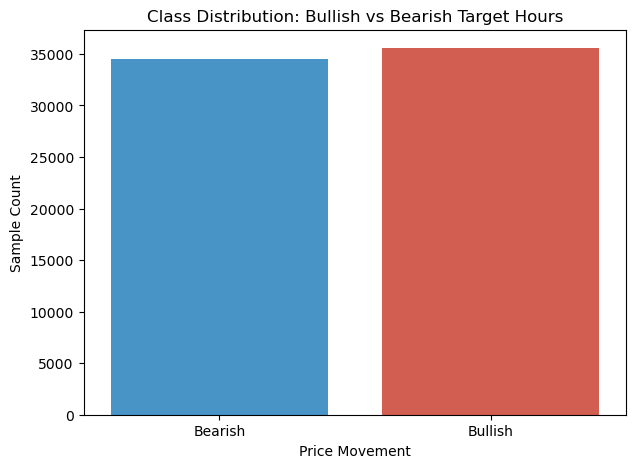

Calculating Feature Correlations with target_return...


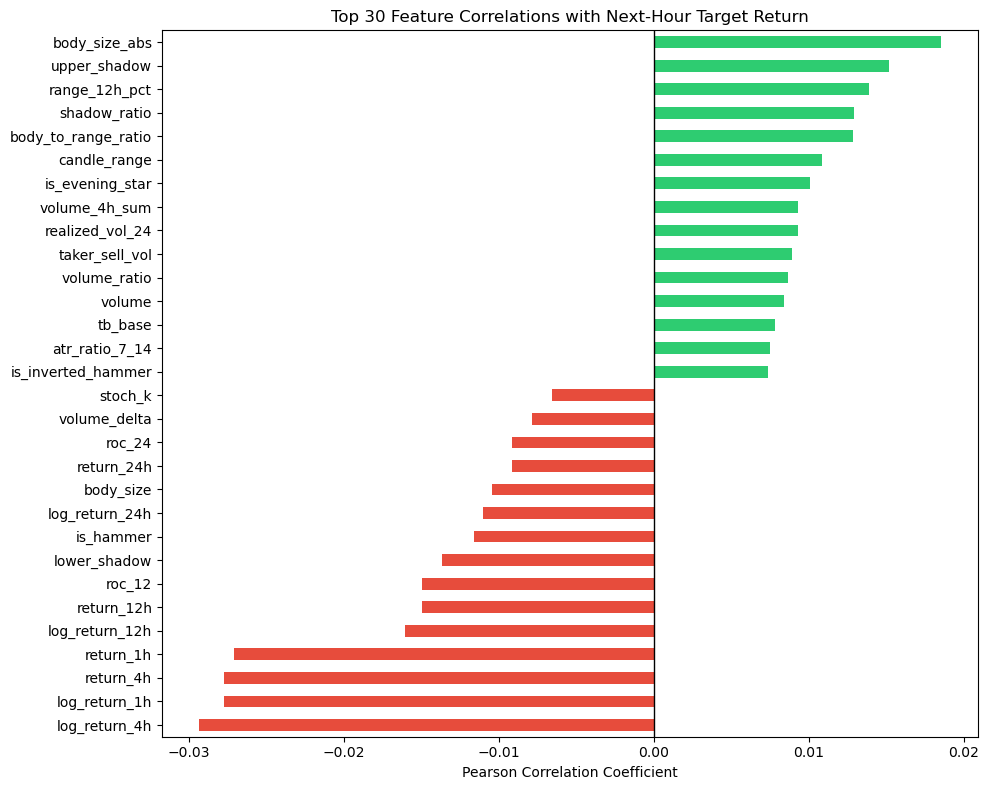


  STATISTICAL VALIDATION RESULTS
ADF Statistic: -37.5500
ADF p-value: 0.0000e+00
✅ Result: Target is Stationary (p < 0.05). Ready for time-series modeling.

Normality Test p-value: 0.0000e+00
ℹ️ Note: Returns follow a non-normal distribution (standard for high-frequency crypto).

Top 5 Most Correlated Features Significance (p-values):
 - log_return_4h         : r=-0.0293, p=7.9312e-15
 - log_return_1h         : r=-0.0277, p=2.1655e-13
 - return_4h             : r=-0.0277, p=2.1673e-13
 - return_1h             : r=-0.0271, p=7.0840e-13
 - body_size_abs         : r= 0.0185, p=9.3843e-07


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, normaltest
from statsmodels.tsa.stattools import adfuller

print("Running Feature Relevance and Statistical Tests...\n")

# --- 1. Class Distribution Test ---
plt.figure(figsize=(7, 5))
sns.countplot(data=df_master, x='target_movement', palette=['#3498db', '#e74c3c'])
plt.title("Class Distribution: Bullish vs Bearish Target Hours")
plt.xlabel("Price Movement")
plt.ylabel("Sample Count")
plt.show()

# --- 2. Correlation with Target (Feature Importance Test) ---
# First select ONLY numeric columns
numeric_df = df_master.select_dtypes(include=[np.number])

# Then drop only the target-related columns that are actually in that numeric list
exclude_numeric = ['target_return', 'next_close']
cols_to_check = [c for c in exclude_numeric if c in numeric_df.columns]
feature_df = numeric_df.drop(columns=cols_to_check)

print("Calculating Feature Correlations with target_return...")
correlations = feature_df.corrwith(df_master['target_return']).sort_values()

# Plotting top 15 most positive and top 15 most negative correlations
top_features = pd.concat([correlations.head(15), correlations.tail(15)])
plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color=np.where(top_features > 0, '#2ecc71', '#e74c3c'))
plt.title("Top 30 Feature Correlations with Next-Hour Target Return")
plt.xlabel("Pearson Correlation Coefficient")
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

# --- 3. Statistical Validation ---
print("\n" + "="*40)
print("  STATISTICAL VALIDATION RESULTS")
print("="*40)

# ADF Test for Stationarity
adf_res = adfuller(df_master['target_return'])
print(f"ADF Statistic: {adf_res[0]:.4f}")
print(f"ADF p-value: {adf_res[1]:.4e}")
if adf_res[1] < 0.05:
    print("✅ Result: Target is Stationary (p < 0.05). Ready for time-series modeling.")
else:
    print("⚠️ Warning: Target is Non-Stationary.")

# Normality Test (D'Agostino's K-squared)
k2, p_norm = normaltest(df_master['target_return'])
print(f"\nNormality Test p-value: {p_norm:.4e}")
if p_norm < 0.05:
    print("ℹ️ Note: Returns follow a non-normal distribution (standard for high-frequency crypto).")

# Correlation Significance (P-Values for top 5 features)
print("\nTop 5 Most Correlated Features Significance (p-values):")
top_5 = correlations.abs().sort_values(ascending=False).head(5).index
for feat in top_5:
    r, p_val = pearsonr(df_master[feat], df_master['target_return'])
    print(f" - {feat:22}: r={r:7.4f}, p={p_val:.4e}")

## 3. Experiment Configuration and Feature Grouping

To rigorously test the predictive power of different data types, we define **15 specific feature variations**. Each variation will be tested both with and without the sentiment data to isolate its contribution, resulting in **30 total combinations** tested per time window.

### Configuration Parameters:
* **Training Window:** 4 Months 
* **Testing Window:** 1 Month 
* **Rolling Strategy:** The windows will slide forward by 1 month for each experiment until the end of the dataset.
* **Feature Sets:** Defined based on technical categories (Momentum, Volatility, Candlestick Anatomy, Candlestick Patterns, and Latent HMM Regimes).

In [3]:
from dateutil.relativedelta import relativedelta

# --- 1. Define Feature Groups ---
# Identifying columns from btc_hourly_indicators.csv
ohlcv = ['open', 'high', 'low', 'close', 'volume']
order_flow = ['taker_sell_vol', 'volume_delta', 'avg_trade_size', 'vol_delta_sma_24', 'avg_trade_size_sma_24', 'vol_delta_ema_24']
returns = [c for c in df_master.columns if 'return_' in c and 'target' not in c]
momentum = ['RSI_7', 'RSI_14', 'RSI_28', 'stoch_k', 'stoch_d', 'williams_r', 'roc_12', 'roc_24', 'cci_20', 'autocorr_1h_24h']
trend_ind = ['ema_12', 'ema_26', 'sma_50', 'sma_200', 'MACD_line', 'MACD_signal', 'MACD_histogram', 'ema_12_26_cross', 'price_above_sma_200', 'adx_14']
volatility = ['ATR_14', 'ATR_7', 'atr_ratio_7_14', 'bb_upper', 'bb_lower', 'bb_mid', 'bb_width', 'bb_pct', 'realized_vol_24']
volume = ['volume_sma_24', 'volume_ratio', 'obv', 'obv_ema_24', 'obv_slope_5', 'vwap_ratio']
multi_tf = ['close_4h_sma', 'volume_4h_sum', 'high_12h', 'low_12h', 'range_12h_pct']
temporal = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']

# NEW: Candlestick Features from btc_hourly_candlestick.csv
anatomy = ['body_size', 'body_size_abs', 'upper_shadow', 'lower_shadow', 'candle_range', 'body_to_range_ratio', 'shadow_ratio']
patterns = ['is_doji', 'is_hammer', 'is_inverted_hammer', 'is_engulfing_bullish', 'is_engulfing_bearish', 'is_morning_star', 'is_evening_star', 'is_marubozu']

# Sentiment columns (everything from the sentiment file excluding timestamp)
sentiment_cols = [c for c in df_sentiment.columns if c != 'timestamp']

# --- Define the 15 Variations ---
feature_variations = {
    "1_OHLCV": ohlcv,
    "2_Order_Flow": ohlcv + order_flow,
    "3_Returns": ohlcv + returns,
    "4_Momentum": ohlcv + momentum,
    "5_Trend": ohlcv + trend_ind,
    "6_Volatility": ohlcv + volatility,
    "7_Volume": ohlcv + volume,
    "8_Multi_TF": ohlcv + multi_tf,
    "9_Temporal": ohlcv + temporal,
    "10_All_Indicators": ohlcv + order_flow + returns + momentum + trend_ind + volatility + volume + multi_tf + temporal,
    
    # NEW Variations
    "11_Candle_Anatomy": ohlcv + anatomy,
    "12_Candle_Patterns": ohlcv + patterns,
    "13_Candle_Full": ohlcv + anatomy + patterns,
    "14_HMM_Only": ohlcv + ['hmm_regime'],
    "15_All_Comprehensive": ohlcv + order_flow + returns + momentum + trend_ind + volatility + volume + multi_tf + temporal + anatomy + patterns + ['hmm_regime']
}

# --- 2. Rolling Window Configuration ---
train_window_months = 4 
test_window_months = 1  

def get_rolling_windows(df, train_m, test_m):
    windows = []
    start_date = df['timestamp'].min()
    end_limit = df['timestamp'].max()
    
    current_train_start = start_date
    while True:
        train_end = current_train_start + relativedelta(months=train_m)
        test_end = train_end + relativedelta(months=test_m)
        
        if test_end > end_limit:
            break
            
        windows.append({
            'train_start': current_train_start,
            'train_end': train_end,
            'test_start': train_end,
            'test_end': test_end
        })
        
        # Slide forward by 1 month 
        current_train_start = current_train_start + relativedelta(months=1)
        
    return windows

rolling_windows = get_rolling_windows(df_master, train_window_months, test_window_months)
print(f"Total experiments to run: {len(rolling_windows)} windows x {len(feature_variations) * 2} combinations = {len(rolling_windows) * len(feature_variations) * 2} total models.")
print(f"Example Experiment 1: Train {rolling_windows[0]['train_start'].date()} to {rolling_windows[0]['train_end'].date()} | Test until {rolling_windows[0]['test_end'].date()}")

Total experiments to run: 91 windows x 30 combinations = 2730 total models.
Example Experiment 1: Train 2018-01-01 to 2018-05-01 | Test until 2018-06-01


## 4. Model Evaluation Metrics

This section defines the engine for our experiments:
1. **Absolute Price Metrics:** Calculates SMAPE, MAPE, RMSE, MAE, and MSE on reconstructed dollar prices to avoid near-zero denominator inflation.
2. **Return Metrics:** Calculates Directional Accuracy (DA) and Information Coefficient (IC) on the fractional returns to evaluate trend prediction.

In [4]:
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from scipy.stats import spearmanr

# --- 1. Metric Functions ---
def calculate_metrics(y_true_ret, y_pred_ret, y_true_price, y_pred_price):
    """
    Calculates error metrics on reconstructed absolute prices (to fix SMAPE/MAPE),
    and directional/correlation metrics on the fractional returns.
    """
    # 1. Absolute Price Metrics
    mse = mean_squared_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_price, y_pred_price)
    
    # Using absolute prices for denominators fixes the fractional return inflation
    denominator = (np.abs(y_true_price) + np.abs(y_pred_price)) / 2.0
    smape = np.mean(np.abs(y_true_price - y_pred_price) / (denominator + 1e-10)) * 100
    mape_val = np.mean(np.abs((y_true_price - y_pred_price) / (y_true_price + 1e-10))) * 100

    # 2. Return Metrics (Direction and Correlation)
    da = np.mean(np.sign(y_true_ret) == np.sign(y_pred_ret)) * 100
    
    # Information Coefficient (Spearman Rank Correlation)
    if np.std(y_true_ret) == 0 or np.std(y_pred_ret) == 0:
        ic = 0.0
    else:
        ic, _ = spearmanr(y_true_ret, y_pred_ret)
        if np.isnan(ic):
            ic = 0.0
            
    # Include R2 for completeness, calculated on the price
    r2 = r2_score(y_true_price, y_pred_price)
        
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape_val,
        'SMAPE': smape,
        'DA': da,
        'IC': ic
    }

print("✅ Metrics objective defined.")

✅ Metrics objective defined.


## 5. Main Walk-Forward Experiment Loop (LSTM)

This loop executes the core training strategy with integrated regime detection and deep learning sequence modeling:
1. **Iterates** through each 4-month train / 1-month test window.
2. **HMM Regime Detection:** Trains a Gaussian HMM *once* per window on historical returns and volatility to classify the latent market state.
3. **Sequence Generation:** Transforms the 2D tabular data into 3D sequences `(samples, time_steps, features)` using a 24-hour lookback window.
4. **Feature Scaling:** Applies `StandardScaler` to stabilize the neural network gradients.
5. **Tests Variations:** Evaluates the 15 feature variations, both with and without Sentiment (30 total).
6. **Hyperparameter Tuning:** Uses Optuna to dynamically find the optimal LSTM parameters (`lstm_units`, `dropout_rate`, `learning_rate`) with Early Stopping.
7. **Price Reconstruction:** Converts predicted fractional returns back into absolute dollar prices to accurately calculate SMAPE and MAPE.
8. **Incremental Saving:** Saves results to `walk_forward_results_lstm.csv` after every single iteration.

In [5]:
import time
import os
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import TPESampler
from tqdm.auto import tqdm
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import copy

# --- PyTorch Deep Learning Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

optuna.logging.set_verbosity(optuna.logging.WARNING) 

csv_filename = 'walk_forward_results_lstm.csv'
results = []
completed_windows = set()

# ==========================================
# RESUME LOGIC (CHECKPOINTING)
# ==========================================
if os.path.exists(csv_filename):
    print(f"📂 Found existing progress in '{csv_filename}'. Loading...")
    existing_df = pd.read_csv(csv_filename)
    results = existing_df.to_dict('records')
    window_counts = existing_df['Window'].value_counts()
    completed_windows = set(window_counts[window_counts == (len(feature_variations) * 2)].index)
    print(f"⏩ Skipping {len(completed_windows)} fully completed windows...")
else:
    print("🚀 Starting fresh Walk-Forward Validation with PyTorch LSTM...")

print(f"Total windows to process: {len(rolling_windows)}")

n_optuna_trials = 30 
TIME_STEPS = 24      

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps - 1]) 
    return np.array(Xs), np.array(ys)

# --- PyTorch Model Architecture ---
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_dim, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_dim)
        out, _ = self.lstm(x)
        # Take the last time step
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# --- Custom PyTorch Early Stopping ---
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

for i, window in enumerate(tqdm(rolling_windows)):
    window_id = i + 1
    
    if window_id in completed_windows:
        continue
        
    train_start, train_end = window['train_start'], window['train_end']
    test_start, test_end = window['test_start'], window['test_end']
    
    train_df = df_master[(df_master['timestamp'] >= train_start) & (df_master['timestamp'] < train_end)].copy()
    test_df = df_master[(df_master['timestamp'] >= test_start) & (df_master['timestamp'] < test_end)].copy()
    
    if len(train_df) < (100 + TIME_STEPS) or len(test_df) < (24 + TIME_STEPS):
        continue
        
    # ==========================================
    # HMM LATENT REGIME DETECTION 
    # ==========================================
    hmm_features = ['return_1h', 'realized_vol_24'] 
    
    X_train_hmm = train_df[hmm_features].fillna(0).values
    X_test_hmm = test_df[hmm_features].fillna(0).values
    
    hmm_scaler = StandardScaler()
    X_train_hmm_scaled = hmm_scaler.fit_transform(X_train_hmm)
    X_test_hmm_scaled = hmm_scaler.transform(X_test_hmm)
    
    hmm_model = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42, min_covar=1e-6)
    hmm_model.fit(X_train_hmm_scaled)
    
    train_df['hmm_regime'] = hmm_model.predict(X_train_hmm_scaled)
    test_df['hmm_regime'] = hmm_model.predict(X_test_hmm_scaled)
    # ==========================================
        
    for var_name, base_features in feature_variations.items():
        for use_sentiment in [False, True]:
            
            already_done = any(r['Window'] == window_id and r['Feature_Variation'] == var_name and r['Uses_Sentiment'] == use_sentiment for r in results)
            if already_done:
                continue
                
            current_features = base_features.copy()
            if use_sentiment:
                current_features.extend(sentiment_cols)
            
            valid_features = [f for f in current_features if f in train_df.columns]
            
            train_subset = train_df[valid_features + ['target_return']].replace([np.inf, -np.inf], np.nan).ffill().bfill()
            test_subset = test_df[valid_features + ['target_return']].replace([np.inf, -np.inf], np.nan).ffill().bfill()
            
            if len(train_subset) <= TIME_STEPS or len(test_subset) <= TIME_STEPS:
                continue

            X_train_raw = train_subset[valid_features].values
            y_train_raw = train_subset['target_return'].values
            X_test_raw = test_subset[valid_features].values
            y_test_raw = test_subset['target_return'].values
            
            # --- SCALE FEATURES ---
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_raw)
            X_test_scaled = scaler.transform(X_test_raw)

            # --- GENERATE SEQUENCES ---
            X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_raw, TIME_STEPS)
            X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_raw, TIME_STEPS)

            # --- PREPARE PYTORCH TENSORS ---
            input_dim = X_train_seq.shape[2]
            X_test_t = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

            # -----------------------------------------------------
            # OPTUNA HYPERPARAMETER TUNING FOR LSTM
            # -----------------------------------------------------
            def objective(trial):
                lstm_units = trial.suggest_categorical('lstm_units', [32, 64, 128])
                dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
                learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
                
                model = LSTMModel(input_dim, lstm_units, dropout_rate).to(device)
                optimizer = optim.Adam(model.parameters(), lr=learning_rate)
                criterion = nn.MSELoss()
                
                split_idx = int(len(X_train_seq) * 0.8)
                X_t = torch.tensor(X_train_seq[:split_idx], dtype=torch.float32)
                y_t = torch.tensor(y_train_seq[:split_idx], dtype=torch.float32).view(-1, 1)
                X_v = torch.tensor(X_train_seq[split_idx:], dtype=torch.float32).to(device)
                y_v = torch.tensor(y_train_seq[split_idx:], dtype=torch.float32).view(-1, 1).to(device)
                
                train_loader = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=False)
                early_stopping = EarlyStopping(patience=3)
                
                for epoch in range(15):
                    model.train()
                    for batch_X, batch_y in train_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                        optimizer.zero_grad()
                        outputs = model(batch_X)
                        loss = criterion(outputs, batch_y)
                        loss.backward()
                        optimizer.step()
                        
                    # Validation phase
                    model.eval()
                    with torch.no_grad():
                        val_preds = model(X_v)
                        val_loss = criterion(val_preds, y_v).item()
                        
                    early_stopping(val_loss, model)
                    if early_stopping.early_stop:
                        break
                        
                # Load best weights
                model.load_state_dict(early_stopping.best_model_state)
                model.eval()
                with torch.no_grad():
                    preds = model(X_v).cpu().numpy().flatten()
                    
                return mean_squared_error(y_v.cpu().numpy().flatten(), preds)
            
            sampler = TPESampler(n_startup_trials=5, seed=42)
            study = optuna.create_study(direction='minimize', sampler=sampler)
            study.optimize(objective, n_trials=n_optuna_trials, show_progress_bar=False)
            
            # --- Train Final Model with Best Params ---
            best_params = study.best_params
            final_model = LSTMModel(input_dim, best_params['lstm_units'], best_params['dropout_rate']).to(device)
            optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'])
            criterion = nn.MSELoss()
            
            split_idx_final = int(len(X_train_seq) * 0.9)
            X_t_final = torch.tensor(X_train_seq[:split_idx_final], dtype=torch.float32)
            y_t_final = torch.tensor(y_train_seq[:split_idx_final], dtype=torch.float32).view(-1, 1)
            X_v_final = torch.tensor(X_train_seq[split_idx_final:], dtype=torch.float32).to(device)
            y_v_final = torch.tensor(y_train_seq[split_idx_final:], dtype=torch.float32).view(-1, 1).to(device)
            
            train_loader_final = DataLoader(TensorDataset(X_t_final, y_t_final), batch_size=64, shuffle=False)
            early_stopping_final = EarlyStopping(patience=4)
            
            for epoch in range(30):
                final_model.train()
                for batch_X, batch_y in train_loader_final:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    optimizer.zero_grad()
                    outputs = final_model(batch_X)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    optimizer.step()
                    
                # Validation phase
                final_model.eval()
                with torch.no_grad():
                    val_preds = final_model(X_v_final)
                    val_loss = criterion(val_preds, y_v_final).item()
                    
                early_stopping_final(val_loss, final_model)
                if early_stopping_final.early_stop:
                    break

            # Predict on Test Set
            final_model.load_state_dict(early_stopping_final.best_model_state)
            final_model.eval()
            with torch.no_grad():
                pred_returns = final_model(X_test_t).cpu().numpy().flatten()
            
            # ==========================================
            # ABSOLUTE PRICE RECONSTRUCTION 
            # ==========================================
            current_closes = test_subset['close'].values[TIME_STEPS:]
            
            actual_prices = current_closes * (1 + y_test_seq)
            predicted_prices = current_closes * (1 + pred_returns)
            
            metrics = calculate_metrics(y_test_seq, pred_returns, actual_prices, predicted_prices)
            
            results.append({
                'Window': window_id,
                'Train_Start': train_start.date(),
                'Test_Start': test_start.date(),
                'Feature_Variation': var_name,
                'Uses_Sentiment': use_sentiment,
                **metrics,
                'Best_Params': str(best_params)
            })
            
            pd.DataFrame(results).to_csv(csv_filename, index=False)

print(f"\n✅ Walk-Forward Validation Complete! Data fully saved to '{csv_filename}'")

🚀 Starting fresh Walk-Forward Validation with PyTorch LSTM...
Total windows to process: 91


  0%|          | 0/91 [00:00<?, ?it/s]


✅ Walk-Forward Validation Complete! Data fully saved to 'walk_forward_results_lstm.csv'


## 6. Model Explainability: Deep Learning SHAP Analysis

To break open the "black box" of the LSTM model and provide academic transparency, we use SHAP (SHapley Additive exPlanations) via `GradientExplainer`. This analysis reveals exactly how much each feature contributes to pushing the model's prediction toward a Bullish (positive return) or Bearish (negative return) forecast.

**Methodology for 3D Sequences:**
1. **Model Training:** We train a final explainer LSTM using the ultimate, most comprehensive feature set (`15_All_Comprehensive` + Sentiment) on the most recent dataset window.
2. **GradientExplainer:** Computes expected gradients using a background dataset to trace back feature attributions.
3. **Temporal Aggregation:** Because the LSTM input is 3D `(samples, time_steps, features)`, SHAP calculates an attribution for every single hour in the lookback window. We sum these attributions across the time steps to evaluate the overall importance of a feature.
4. **SHAP Summary Plot:** Shows the directional distribution of feature impacts using the most recent observation in the sequence for reference.

In [6]:
import ast
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("Generating SHAP Explainability Analysis for PyTorch LSTM...")

TIME_STEPS = 24

# --- 1. Select a Representative Window for Analysis ---
final_window = rolling_windows[-1]
train_start, train_end = final_window['train_start'], final_window['train_end']
test_start, test_end = final_window['test_start'], final_window['test_end']

train_df = df_master[(df_master['timestamp'] >= train_start) & (df_master['timestamp'] < train_end)].copy()
test_df = df_master[(df_master['timestamp'] >= test_start) & (df_master['timestamp'] < test_end)].copy()

# --- 2. HMM Regime Extraction for Final Window ---
hmm_features = ['return_1h', 'realized_vol_24'] 
X_train_hmm = train_df[hmm_features].fillna(0).values
X_test_hmm = test_df[hmm_features].fillna(0).values

hmm_scaler = StandardScaler()
X_train_hmm_scaled = hmm_scaler.fit_transform(X_train_hmm)
X_test_hmm_scaled = hmm_scaler.transform(X_test_hmm)

hmm_model = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42, min_covar=1e-6)
hmm_model.fit(X_train_hmm_scaled)

train_df['hmm_regime'] = hmm_model.predict(X_train_hmm_scaled)
test_df['hmm_regime'] = hmm_model.predict(X_test_hmm_scaled)

# --- 3. Define the Feature Set ---
features_to_use = feature_variations['15_All_Comprehensive'] + sentiment_cols
valid_features_shap = [f for f in features_to_use if f in train_df.columns]

train_subset = train_df[valid_features_shap + ['target_return']].replace([np.inf, -np.inf], np.nan).ffill().bfill()
test_subset = test_df[valid_features_shap + ['target_return']].replace([np.inf, -np.inf], np.nan).ffill().bfill()

X_train_raw = train_subset[valid_features_shap].values
y_train_raw = train_subset['target_return'].values
X_test_raw = test_subset[valid_features_shap].values
y_test_raw = test_subset['target_return'].values

# --- 4. Scale and Sequence ---
shap_scaler = StandardScaler()
X_train_scaled = shap_scaler.fit_transform(X_train_raw)
X_test_scaled = shap_scaler.transform(X_test_raw)

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps - 1]) 
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_raw, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_raw, TIME_STEPS)
input_dim = X_train_seq.shape[2]

# --- 5. Dynamically Load Best Parameters ---
try:
    results_df = pd.read_csv('walk_forward_results_lstm.csv')
    target_row = results_df[(results_df['Feature_Variation'] == '15_All_Comprehensive') & 
                            (results_df['Uses_Sentiment'] == True)].iloc[-1]
    best_params = ast.literal_eval(target_row['Best_Params'])
    print(f"Loaded optimized parameters for SHAP model: {best_params}")
except Exception as e:
    print("Could not load optimized parameters. Defaulting to standard architecture.")
    best_params = {'lstm_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001}

# --- 6. Train the Explainer Model (PyTorch) ---
shap_model = LSTMModel(input_dim, best_params['lstm_units'], best_params['dropout_rate']).to(device)
optimizer = optim.Adam(shap_model.parameters(), lr=best_params['learning_rate'])
criterion = nn.MSELoss()

print("Training Explainer LSTM...")
split_idx_shap = int(len(X_train_seq) * 0.9)
X_t_shap = torch.tensor(X_train_seq[:split_idx_shap], dtype=torch.float32)
y_t_shap = torch.tensor(y_train_seq[:split_idx_shap], dtype=torch.float32).view(-1, 1)
X_v_shap = torch.tensor(X_train_seq[split_idx_shap:], dtype=torch.float32).to(device)
y_v_shap = torch.tensor(y_train_seq[split_idx_shap:], dtype=torch.float32).view(-1, 1).to(device)

train_loader_shap = DataLoader(TensorDataset(X_t_shap, y_t_shap), batch_size=64, shuffle=False)
early_stopping_shap = EarlyStopping(patience=3)

for epoch in range(15):
    shap_model.train()
    for batch_X, batch_y in train_loader_shap:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = shap_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
    shap_model.eval()
    with torch.no_grad():
        val_preds = shap_model(X_v_shap)
        val_loss = criterion(val_preds, y_v_shap).item()
        
    early_stopping_shap(val_loss, shap_model)
    if early_stopping_shap.early_stop:
        break

shap_model.load_state_dict(early_stopping_shap.best_model_state)
shap_model.eval() # Ensure model is in evaluation mode for SHAP

# --- 7. Calculate SHAP Values via GradientExplainer ---
print("Calculating Deep Learning SHAP Values (this may take a minute)...")
# Convert background and test data to PyTorch tensors and send to GPU
background_data = torch.tensor(X_train_seq[:200], dtype=torch.float32).to(device)
test_data_to_explain = torch.tensor(X_test_seq[:200], dtype=torch.float32).to(device)

explainer = shap.GradientExplainer(shap_model, background_data)
shap_values_raw = explainer.shap_values(test_data_to_explain)

# SHAP values might come back as a list depending on output dimensions
shap_values_3d = shap_values_raw[0] if isinstance(shap_values_raw, list) else shap_values_raw

# --- 8. Transform 3D to 2D for Visualizations ---
shap_values_magnitude = np.sum(np.abs(shap_values_3d), axis=1)
shap_values_directional = np.sum(shap_values_3d, axis=1)

X_test_2d = test_data_to_explain.cpu().numpy()[:, -1, :]

# --- 9. Visualizations & Saving for Thesis ---
print("\nPlotting SHAP Feature Importance Ranking...")
plt.figure(figsize=(10, 8))
plt.title("PyTorch LSTM SHAP Feature Importance (Absolute Magnitude over 24h)")
shap.summary_plot(shap_values_magnitude, X_test_2d, feature_names=valid_features_shap, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("LSTM_SHAP_Feature_Importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nPlotting SHAP Summary (Directional Impact)...")
plt.figure(figsize=(10, 8))
plt.title("PyTorch LSTM SHAP Summary Plot: Net Directional Impact over 24h")
shap.summary_plot(shap_values_directional, X_test_2d, feature_names=valid_features_shap, show=False)
plt.tight_layout()
plt.savefig("LSTM_SHAP_Summary_Plot.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ SHAP Analysis Complete. High-resolution plots saved for your thesis.")

Generating SHAP Explainability Analysis for PyTorch LSTM...
Loaded optimized parameters for SHAP model: {'lstm_units': 128, 'dropout_rate': 0.36048032800397883, 'learning_rate': 0.00658856690931576}
Training Explainer LSTM...
Calculating Deep Learning SHAP Values (this may take a minute)...


RuntimeError: cudnn RNN backward can only be called in training mode

## 7. Thesis Report Generation

This final block compiles all results from the Walk-Forward Validation into a highly detailed Microsoft Word document (`.docx`) ready for thesis integration.

**The report includes:**
1. Methodology Overview (LSTM Architecture & Sequence Modeling).
2. Best & Worst Data Combinations per Metric (Averaged across all windows).
3. Extreme Windows Analysis (Top 5 and Bottom 5 windows per combination, mapped to 6 decimal places).
4. Complete Chronological Experimental Logs.

In [ ]:
import pandas as pd
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

def generate_detailed_results_doc():
    print("🚀 Generating Comprehensive 'LSTM_Results.docx'...")
    
    try:
        # CHANGED: Read from the new LSTM results file
        df = pd.read_csv("walk_forward_results_lstm.csv")
    except FileNotFoundError:
        print("❌ Error: 'walk_forward_results_lstm.csv' not found. Run the training loop first.")
        return

    doc = Document()
    
    # --- SECTION 1: TITLE & METHODOLOGY ---
    # CHANGED: Title to reflect LSTM
    title = doc.add_heading('Experimental Results: LSTM Regression', 0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_heading('1. Training & Testing Methodology', level=1)
    doc.add_paragraph("Walk-Forward Validation strategy (4-month train, 1-month test) sliding forward month-by-month. "
                      "Model integrates a Gaussian HMM for latent regime detection, 24-hour sequence lookbacks for LSTM, and absolute price reconstruction for evaluation.")

    # --- SECTION 2: BEST & WORST COMBINATION PER METRIC ---
    doc.add_heading('2. Best & Worst Data Combination per Metric', level=1)
    doc.add_paragraph("This table shows which specific feature + sentiment combination performed the best and worst overall for each individual evaluation metric (averaged across all windows).")

    metrics_goals = {
        'RMSE': 'min', 'MSE': 'min', 'MAE': 'min', 'MAPE': 'min', 'SMAPE': 'min',
        'R2': 'max', 'DA': 'max', 'IC': 'max'
    }

    feature_avg = df.groupby(['Feature_Variation', 'Uses_Sentiment']).mean(numeric_only=True).reset_index()

    comb_table = doc.add_table(rows=1, cols=5)
    comb_table.style = 'Table Grid'
    hdr = comb_table.rows[0].cells
    hdr[0].text, hdr[1].text, hdr[2].text, hdr[3].text, hdr[4].text = 'Metric', 'BEST Combination', 'Value', 'WORST Combination', 'Value'

    for metric, goal in metrics_goals.items():
        if goal == 'min':
            best_idx = feature_avg[metric].idxmin()
            worst_idx = feature_avg[metric].idxmax()
        else:
            best_idx = feature_avg[metric].idxmax()
            worst_idx = feature_avg[metric].idxmin()

        best_row = feature_avg.iloc[best_idx]
        worst_row = feature_avg.iloc[worst_idx]

        best_clean = str(best_row['Feature_Variation']).split('_', 1)[1]
        worst_clean = str(worst_row['Feature_Variation']).split('_', 1)[1]

        row = comb_table.add_row().cells
        row[0].text = metric
        row[1].text = f"{best_clean} (Sent: {'Y' if best_row['Uses_Sentiment'] else 'N'})"
        row[2].text = f"{best_row[metric]:.6f}" 
        row[3].text = f"{worst_clean} (Sent: {'Y' if worst_row['Uses_Sentiment'] else 'N'})"
        row[4].text = f"{worst_row[metric]:.6f}" 

    # --- SECTION 3: TOP 5 / BOTTOM 5 WINDOWS PER COMBINATION & METRIC ---
    doc.add_page_break()
    doc.add_heading('3. Extreme Windows per Data Combination', level=1)
    doc.add_paragraph("For every feature and sentiment combination, this section lists the Top 5 (Best) and Bottom 5 (Worst) testing windows for each metric.")

    combinations = df[['Feature_Variation', 'Uses_Sentiment']].drop_duplicates()
    
    combinations['sort_num'] = combinations['Feature_Variation'].str.extract(r'^(\d+)').astype(int)
    combinations = combinations.sort_values(by=['sort_num', 'Uses_Sentiment'], ascending=[True, False])
    
    for _, comb in combinations.iterrows():
        feature = comb['Feature_Variation']
        sent = comb['Uses_Sentiment']
        sent_str = "WITH Sentiment" if sent else "NO Sentiment"
        
        feature_clean = str(feature).split('_', 1)[1]
        doc.add_heading(f"{feature_clean} | {sent_str}", level=2)
        
        f_df = df[(df['Feature_Variation'] == feature) & (df['Uses_Sentiment'] == sent)]
        
        ext_table = doc.add_table(rows=1, cols=3)
        ext_table.style = 'Light Shading Accent 1'
        ext_hdr = ext_table.rows[0].cells
        ext_hdr[0].text, ext_hdr[1].text, ext_hdr[2].text = 'Metric', 'Top 5 Windows (Best First)', 'Bottom 5 Windows (Worst First)'
        
        for metric, goal in metrics_goals.items():
            ascending_sort = True if goal == 'min' else False
            sorted_df = f_df.sort_values(by=metric, ascending=ascending_sort)
            
            top_5 = sorted_df.head(5)
            top_str = ", ".join([f"W{int(r['Window'])} ({r[metric]:.6f})" for _, r in top_5.iterrows()])
            
            bottom_5 = sorted_df.tail(5).iloc[::-1]
            bot_str = ", ".join([f"W{int(r['Window'])} ({r[metric]:.6f})" for _, r in bottom_5.iterrows()])
            
            row = ext_table.add_row().cells
            row[0].text = metric
            row[1].text = top_str
            row[2].text = bot_str
            
            for cell in row:
                for paragraph in cell.paragraphs:
                    for run in paragraph.runs:
                        run.font.size = Pt(8)

    # --- SECTION 4: COMPLETE EXPERIMENTAL LOGS ---
    doc.add_page_break()
    doc.add_heading('4. Complete Experimental Logs', level=1)
    doc.add_paragraph("Chronologically sorted by Window, grouped by Feature Variation.")

    full_table = doc.add_table(rows=1, cols=10)
    full_table.style = 'Table Grid'
    f_headers = ['W#', 'Features', 'Sent', 'RMSE', 'MAE', 'R2', 'MAPE', 'SMAPE', 'DA%', 'IC']
    h_cells = full_table.rows[0].cells
    for i, h in enumerate(f_headers): h_cells[i].text = h

    df['sort_num'] = df['Feature_Variation'].str.extract(r'^(\d+)').astype(int)
    df_sorted = df.sort_values(by=['Window', 'sort_num', 'Uses_Sentiment'], ascending=[True, True, False])
    
    for _, row in df_sorted.iterrows():
        c = full_table.add_row().cells
        c[0].text = str(int(row['Window']))
        
        clean_feature_name = str(row['Feature_Variation']).split('_', 1)[1]
        c[1].text = clean_feature_name
        
        c[2].text = 'Y' if row['Uses_Sentiment'] else 'N'
        c[3].text = f"{row['RMSE']:.6f}" 
        c[4].text = f"{row['MAE']:.6f}" 
        c[5].text = f"{row['R2']:.4f}"
        c[6].text = f"{row['MAPE']:.4f}"
        c[7].text = f"{row['SMAPE']:.4f}"
        c[8].text = f"{row['DA']:.2f}"
        c[9].text = f"{row['IC']:.6f}" 
        
        for cell in c:
            for paragraph in cell.paragraphs:
                for run in paragraph.runs:
                    run.font.size = Pt(8)

    # CHANGED: Save as LSTM_Results.docx
    doc.save("LSTM_Results.docx")
    print("✅ Successfully saved highly-detailed report to 'LSTM_Results.docx'")

generate_detailed_results_doc()